In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


OpenStereo is already cloned.
Optional FoundationStereo imports disabled.


2026-07-30 21:17:02,308   INFO  Loading parameters from checkpoint /content/OpenStereo/pretrained/checkpoint/LightStereo/LightStereo-S-SceneFlow.ckpt
2026-07-30 21:17:02,308   INFO  Loading parameters from checkpoint /content/OpenStereo/pretrained/checkpoint/LightStereo/LightStereo-S-SceneFlow.ckpt


Checkpoint downloaded temporarily: /content/OpenStereo/pretrained/checkpoint/LightStereo/LightStereo-S-SceneFlow.ckpt
GPU: Tesla T4


2026-07-30 21:17:02,409   INFO  Unused weight: 
2026-07-30 21:17:02,409   INFO  Unused weight: 
2026-07-30 21:17:02,411   INFO  Not updated weight: 
2026-07-30 21:17:02,411   INFO  Not updated weight: 


Original size: (1110, 1390)
Padded size:   (1120, 1408)
Disparity shape: (1110, 1390)
Disparity range: 11.772072792053223 to 187.99386596679688


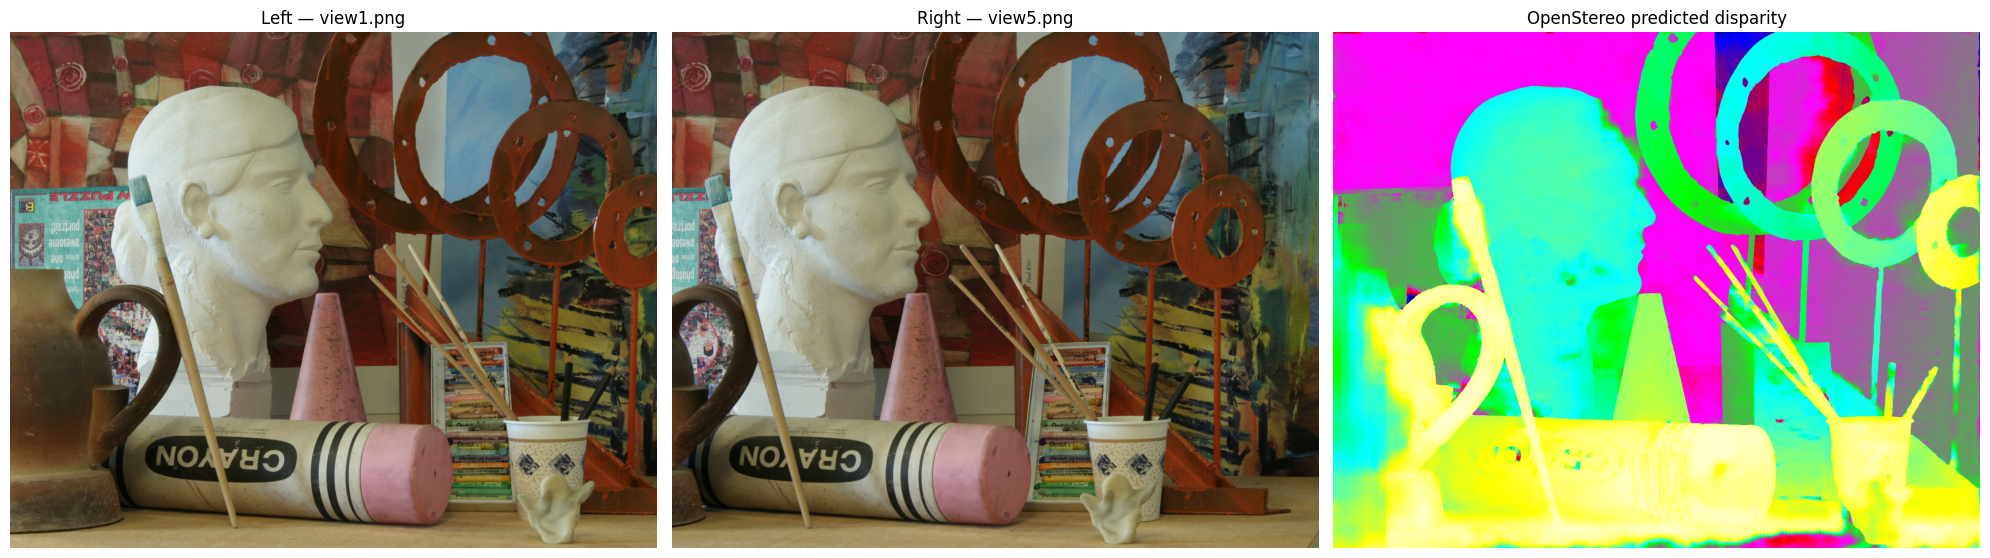

In [ ]:
import os
import sys
import subprocess
from pathlib import Path
from argparse import Namespace

# --------------------------------------------------
# Input paths
# --------------------------------------------------
workpath = "/content/drive/MyDrive/DigitalImageProcessing/"

IMG1 = workpath + "Data/view1.png"  # left
IMG2 = workpath + "Data/view5.png"  # right

repo = Path("/content/OpenStereo")
checkpoint_dir = repo / "pretrained"

assert os.path.isfile(IMG1), f"Missing left image: {IMG1}"
assert os.path.isfile(IMG2), f"Missing right image: {IMG2}"

# --------------------------------------------------
# Clone OpenStereo
# --------------------------------------------------
if not repo.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--branch",
            "v2",
            "--depth",
            "1",
            "https://github.com/XiandaGuo/OpenStereo.git",
            str(repo),
        ],
        check=True,
    )
else:
    print("OpenStereo is already cloned.")

# Restore this file in case the cell is rerun
subprocess.run(
    ["git", "checkout", "--", "stereo/modeling/__init__.py"],
    cwd=repo,
    check=True,
)

# --------------------------------------------------
# Install dependencies
# --------------------------------------------------
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(repo / "requirements.txt"),
    ],
    check=True,
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "huggingface_hub",
    ],
    check=True,
)

# --------------------------------------------------
# Disable optional FoundationStereo imports
# They require extra dependencies, but this notebook
# only uses LightStereo.
# --------------------------------------------------
init_file = repo / "stereo/modeling/__init__.py"
lines = init_file.read_text().splitlines()


def disable_optional_model(lines, import_text, variable_name):
    import_index = next(
        i for i, line in enumerate(lines)
        if import_text in line
    )

    start_index = next(
        i for i in range(import_index, -1, -1)
        if lines[i].strip() == "try:"
    )

    end_index = next(
        i for i in range(import_index + 1, len(lines))
        if "Otherwise you can comment out this line of code" in lines[i]
    )

    lines[start_index:end_index + 1] = [
        f"# {variable_name} disabled; this notebook uses LightStereo.",
        f"{variable_name} = None",
    ]

    return lines


lines = disable_optional_model(
    lines,
    "models.foundationstereo.trainer",
    "FoundationStereoTrainer",
)

lines = disable_optional_model(
    lines,
    "models.fast_foundationstereo.trainer",
    "FastFoundationStereoTrainer",
)

init_file.write_text("\n".join(lines) + "\n")

# Verify that the edited file is valid Python
subprocess.run(
    [sys.executable, "-m", "py_compile", str(init_file)],
    check=True,
)

print("Optional FoundationStereo imports disabled.")

# --------------------------------------------------
# Download the checkpoint temporarily to /content
# --------------------------------------------------
from huggingface_hub import hf_hub_download

checkpoint = hf_hub_download(
    repo_id="XiandaGuo/OpenStereo",
    filename=(
        "checkpoint/LightStereo/"
        "LightStereo-S-SceneFlow.ckpt"
    ),
    local_dir=str(checkpoint_dir),
)

print("Checkpoint downloaded temporarily:", checkpoint)

# --------------------------------------------------
# Imports for inference
# --------------------------------------------------
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from easydict import EasyDict

assert torch.cuda.is_available(), (
    "No GPU detected. In Colab, select "
    "Runtime → Change runtime type → T4 GPU."
)

print("GPU:", torch.cuda.get_device_name(0))

os.chdir(repo)

repo_string = str(repo)
if repo_string not in sys.path:
    sys.path.insert(0, repo_string)

from stereo.utils import common_utils
from stereo.modeling import build_trainer
from stereo.utils.disp_color import disp_to_color
from stereo.datasets.dataset_template import build_transform_by_cfg

# --------------------------------------------------
# Load configuration
# --------------------------------------------------
config_path = "cfgs/lightstereo/lightstereo_s_sceneflow.yaml"

yaml_config = common_utils.config_loader(config_path)
cfgs = EasyDict(yaml_config)
cfgs.MODEL.PRETRAINED_MODEL = checkpoint

args = Namespace(
    dist_mode=False,
    cfg_file=config_path,
    pretrained_model=checkpoint,
    left_img_path=IMG1,
    right_img_path=IMG2,
    savename=None,
    run_mode="infer",
)

device = torch.device("cuda:0")
torch.cuda.set_device(0)

logger = common_utils.create_logger(
    log_file=None,
    rank=0,
)

# --------------------------------------------------
# Load trained model
# --------------------------------------------------
trainer = build_trainer(
    args=args,
    cfgs=cfgs,
    local_rank=0,
    global_rank=0,
    logger=logger,
    tb_writer=None,
)

model = trainer.model
model.eval()

# --------------------------------------------------
# Load input images
# --------------------------------------------------
left_image = np.asarray(
    Image.open(IMG1).convert("RGB"),
    dtype=np.float32,
)

right_image = np.asarray(
    Image.open(IMG2).convert("RGB"),
    dtype=np.float32,
)

assert left_image.shape == right_image.shape, (
    "The left and right images must have identical dimensions."
)

original_height, original_width = left_image.shape[:2]

# LightStereo requires dimensions divisible by 32.
# Pad upward to the nearest valid dimensions.
pad_height = ((original_height + 31) // 32) * 32
pad_width = ((original_width + 31) // 32) * 32

print("Original size:", (original_height, original_width))
print("Padded size:  ", (pad_height, pad_width))

# Replace OpenStereo's fixed padding size with one appropriate
# for the current input images.
transform_config = cfgs.DATA_CONFIG.DATA_TRANSFORM.EVALUATING

for transform_item in transform_config:
    if transform_item.NAME == "RightTopPad":
        transform_item.SIZE = [pad_height, pad_width]

transform = build_transform_by_cfg(transform_config)

sample = transform(
    {
        "left": left_image,
        "right": right_image,
    }
)

sample["left"] = sample["left"].unsqueeze(0).to(device)
sample["right"] = sample["right"].unsqueeze(0).to(device)

# --------------------------------------------------
# Run inference directly in memory
# --------------------------------------------------
with torch.inference_mode():
    with torch.autocast(
        device_type="cuda",
        enabled=cfgs.OPTIMIZATION.AMP,
    ):
        prediction = model(sample)

# Numeric floating-point disparity map
disparity = (
    prediction["disp_pred"]
    .squeeze()
    .float()
    .cpu()
    .numpy()
)

# Remove top and right padding added by preprocessing
disparity = disparity[-original_height:, :original_width]

# Create an in-memory color visualization
disparity_color = disp_to_color(
    disparity,
    max_disp=cfgs.MODEL.MAX_DISP,
).astype(np.uint8)

print("Disparity shape:", disparity.shape)
print(
    "Disparity range:",
    float(np.nanmin(disparity)),
    "to",
    float(np.nanmax(disparity)),
)

# --------------------------------------------------
# Display directly—nothing is saved
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(left_image.astype(np.uint8))
axes[0].set_title("Left — view1.png")

axes[1].imshow(right_image.astype(np.uint8))
axes[1].set_title("Right — view5.png")

axes[2].imshow(disparity_color)
axes[2].set_title("OpenStereo predicted disparity")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()